In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"

import numpy as np
import tensorflow as tf
from tabulate import tabulate
from tensorflow.python.client import device_lib
from tqdm import tqdm
import time

from tensorflow.keras import mixed_precision

tf.keras.mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(False)


2025-10-23 18:08:25.752223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761223105.764910  788950 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761223105.768790  788950 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761223105.778932  788950 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761223105.778951  788950 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761223105.778953  788950 computation_placer.cc:177] computation placer alr

In [2]:

def print_gpu_details():
    """Prints all available GPUs in a formatted table with key details"""
    # Get list of all devices
    devices = device_lib.list_local_devices()
    gpu_details = []
    
    for device in devices:
        if device.device_type == 'GPU':
            # Extract details from the device description string
            desc = device.physical_device_desc
            details = {
                'Device ID': device.name.split(':')[-1],
                'Name': desc.split('name: ')[1].split(',')[0] if 'name: ' in desc else 'Unknown',
                'Memory (GB)': f"{device.memory_limit / (1024**3):.2f}",
                'PCI Bus ID': desc.split('pci bus id: ')[1].split(',')[0] if 'pci bus id: ' in desc else 'Unknown',
                'GFX Version': os.environ.get('HSA_OVERRIDE_GFX_VERSION', 'Native')
            }
            gpu_details.append(details)
    
    # Print table if GPUs found
    if gpu_details:
        print("\n" + "="*85)
        print("ACTIVE GPU CONFIGURATION".center(85))
        print("="*85)
        print(tabulate(gpu_details, headers="keys", tablefmt="grid"))
        print("="*85+ "\n")
    else:
        print("No GPU devices found!")


def configure_gpu(vram_limit):
    """Configure GPU settings with optional GFX override"""
    
    # Verify GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Limit VRAM on the specified GPU
            
            for gid in range(len(gpus)):
                
                tf.config.experimental.set_virtual_device_configuration(
                    gpus[gid],
                    [tf.config.experimental.VirtualDeviceConfiguration(
                        memory_limit=vram_limit[gid] * 1024)]  # Convert GB to MB
                )
                print(f"GPU {gid} VRAM limited to {vram_limit[gid]}GB")
                
        except RuntimeError as e:
            print(f"Error setting VRAM limit: {e}")
    
    if not gpus:
        raise RuntimeError(f"No GPU found")
    
    for gid in range(len(gpus)):
        print(f"Configured GPU {gid}: {tf.config.experimental.get_device_details(gpus[gid])}") 
        
        with tf.device('/GPU:'+str(gid)):  # Force GPU usage
            x = tf.ones((1, 1))    # Smallest possible tensor
            y = x + 1              # Simple operation
            y.numpy()              # Force execution

In [3]:
VRAM = [3.55]

configure_gpu(VRAM)

print_gpu_details()

GPU 0 VRAM limited to 3.55GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}

                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.55 | 0000:01:00.0 | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+



I0000 00:00:1761223109.529910  788950 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1761223109.587614  788950 gpu_device.cc:2019] Created device /device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore

# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (dataset_detail[0],dataset_detail[1])

target = min(int(dataset_detail[2]*0.8),int(2**17+1))
# target=1000

Dmax = dataset_detail[3]

resize_fraction = dataset_detail[4]
resize_factor = 1/resize_fraction

feature_dimension = dataset_detail[5]

disparity_skip = dataset_detail[6]

eff_Dmax = Dmax//(disparity_skip+1)




In [5]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
left_feat_memmap = dataset_org_path + "left_feat.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/"

left_patches  = np.memmap(left_patch_memmap, dtype=np.float16, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
patch_feat =np.memmap(left_feat_memmap, dtype=np.float16, mode='r', shape=(target, feature_dimension))

right_strips  = np.memmap(right_strip_memmap, dtype=np.float16, mode='r', shape=(target, eff_Dmax, patch_shape[0], patch_shape[1] ))
strip_feat =np.memmap(right_feat_memmap, dtype=np.float16, mode='r', shape=(target,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))

default_mask = np.ones((target, eff_Dmax), dtype=bool)



In [6]:
# def data_printer(array):
#     print("Min : ",np.min(array))
#     print("Mean : ",np.mean(array))
#     print("Median : ",np.median(array))
#     print("Max : ",np.max(array))
#     print('\n')
    
# data_printer(left_patches)
# data_printer(patch_feat)
# data_printer(right_strips)
# data_printer(strip_feat)
# data_printer(median_disp)
# data_printer(default_mask)


In [7]:
# -------------------------
# Imports
# -------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import os


# -------------------------
# Checkpoint callback 
# -------------------------
class Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, model_location, save_every=4):
        super().__init__()
        self.model_location = model_location
        self.save_every = save_every
        os.makedirs(model_location, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            filename = os.path.join(self.model_location, f"model_epoch_{epoch+1:02d}.keras")
            self.model.save(filename)
            print(f"\n Saved model checkpoint: {filename}\n")


# -------------------------
# GPU Memory Logger
# -------------------------
class GPUMemoryLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            mem_info = tf.config.experimental.get_memory_info(f'GPU:{self.device_index}')
            used = mem_info['current'] / (1024 ** 2)
            peak = mem_info['peak'] / (1024 ** 2)
            print(f"Batch {batch}: GPU{self.device_index} memory used = {used:.1f} MB | peak = {peak:.1f} MB")
        except Exception as e:
            print(f"Could not fetch GPU info: {e}")
            
import subprocess
import re
import tensorflow as tf

# -------------------------
# GPU Utilization Logger
# -------------------------
class GPUUtilizationLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            result = subprocess.run(
                ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,nounits,noheader', '-i', str(self.device_index)],
                stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
            )
            if result.returncode == 0:
                usage = int(result.stdout.strip())
                print(f"Batch {batch}: GPU{self.device_index} utilization = {usage}%")
            else:
                print(f"Batch {batch}: Could not fetch GPU utilization: {result.stderr.strip()}")
        except Exception as e:
            print(f"Could not fetch GPU utilization: {e}")


checkpoint_cb = Checkpoint(model_location, save_every=5)
gpu_logger = GPUMemoryLogger()
gpu_util = GPUUtilizationLogger()


In [8]:

import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split


class StereoBatchGenerator(Sequence):
    def __init__(self, left_memmap, right_memmap, left_feat, right_feat,disp_mask,
                 disp_memmap, batch_size=32, indices=None, shuffle=True):
        self.left = left_memmap
        self.right = right_memmap
        self.feat_l = left_feat
        self.feat_r = right_feat
        self.mask = disp_mask
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.disp = disp_memmap
        
        # Indices for shuffling
        if indices is None:
            self.indices = np.arange(len(self.left))
        else:
            self.indices = np.array(indices)

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        # Normalize image patches
        left_norm = self.left[batch_idx]
        right_norm = self.right[batch_idx]
        
        left_norm = np.expand_dims(left_norm, axis=-1)
        right_norm = np.expand_dims(right_norm, axis=-1)

        # Features
        patch_feat = self.feat_l[batch_idx]
        strip_feat = self.feat_r[batch_idx]

        # Disparity labels
        disp_batch = self.disp[batch_idx]

        # Mask: all True during training
        strip_mask = self.mask[batch_idx]

        # Return as list of inputs + target
        return (left_norm, right_norm, patch_feat, strip_feat, strip_mask), disp_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [9]:

# -----------------------------------------------------------
# Custom metric: ±k disparity tolerance
# -----------------------------------------------------------
class DisparityToleranceAccuracy(tf.keras.metrics.Metric):
    def __init__(self, tolerance=2, name='disp_tolerance_acc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.tolerance = tolerance
        self.total = self.add_weight(name='total', initializer='zeros')
        self.correct = self.add_weight(name='correct', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int16)
        y_true = tf.cast(y_true, tf.int16)
        diff = tf.abs(y_pred - y_true)
        correct_within_tol = tf.cast(diff <= self.tolerance, tf.float16)
        self.correct.assign_add(tf.reduce_sum(correct_within_tol))
        self.total.assign_add(tf.cast(tf.size(y_true), tf.float16))

    def result(self):
        return self.correct / self.total

    def reset_states(self):
        self.total.assign(0)
        self.correct.assign(0)


from tensorflow.keras import layers, models, optimizers
import tensorflow as tf


# Custom similarity layer
class DotProductSimilarity(layers.Layer):
    def call(self, inputs):
        left_feat, right_feat = inputs
        left_exp = tf.expand_dims(left_feat, axis=1)  # (batch, 1, features)
        sim = tf.reduce_sum(left_exp * right_feat, axis=-1)  # (batch, Dmax)
        return sim
    
# Custom similarity layer using negative L2 distance
class L2Similarity(layers.Layer):
    def call(self, inputs):
        left_feat, right_feat = inputs
        left_exp = tf.expand_dims(left_feat, axis=1)  # (batch, 1, features)
        diff = left_exp - right_feat                   # (batch, max_d, features)
        sim = -tf.reduce_sum(tf.square(diff), axis=-1) # negative L2 → higher is better
        return sim


# Masked softmax (mask is a boolean tensor of same shape as last dimension)
class MaskedSoftmax(layers.Layer):
    def call(self, inputs, mask_tensor):
        # inputs: [batch, max_d] or [batch, max_d, ...] depending on similarity output
        # mask_tensor: same shape as last dim of inputs
        large_neg = tf.constant(-1e9, dtype=inputs.dtype)
        
        # broadcast mask if needed
        for _ in range(len(inputs.shape) - len(mask_tensor.shape)):
            mask_tensor = tf.expand_dims(mask_tensor, -1)
        
        masked_inputs = tf.where(mask_tensor, inputs, large_neg)
        return tf.nn.softmax(masked_inputs, axis=-1)



# Siamese model with precomputed features + masked softmax + LayerNormalization
def build_model(patch_shape, max_d, feat_dim=5):
    # ---- Inputs ----
    left_input = layers.Input(shape=(*patch_shape, 1), name='left_patch')
    right_input = layers.Input(shape=(max_d, *patch_shape, 1), name='right_strip')
    
    left_feat_input = layers.Input(shape=(feat_dim,), name='left_feat')
    right_feat_input = layers.Input(shape=(max_d, feat_dim), name='right_feat')
    mask_input = layers.Input(shape=(max_d,), dtype=tf.bool, name='mask')

    filters = [8, 16, 32]
    # filters = [16, 32, 64]
    # filters = [32, 64, 128]

    # ---- CNN for image patches ----
    def cnn_extractor(x):
        x = layers.Conv2D(filters[0], (3,3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters[1], (3,3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(filters[2], activation='relu')(x)
        return x

    left_cnn = cnn_extractor(left_input)
    
    right_cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv2D(filters[0], (3,3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            
            layers.Conv2D(filters[1], (3,3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            
            layers.GlobalAveragePooling2D(),
            layers.Dense(filters[2], activation='relu')
        ])
    )(right_input)


    # ---- Dense for normalized features ----
    
    left_feat_dense = layers.Dense(filters[0], activation='relu')(layers.LayerNormalization()(left_feat_input))
    right_feat_dense = layers.TimeDistributed(layers.Dense(filters[0], activation='relu'))(layers.LayerNormalization()(right_feat_input))


    # ---- Concatenate CNN + precomputed features ----
    left_emb = layers.Concatenate()([left_cnn, left_feat_dense])
    right_emb = layers.Concatenate()([right_cnn, right_feat_dense])

    # ---- Similarity ----
    # similarity = DotProductSimilarity()([left_emb, right_emb])
    similarity = L2Similarity()([left_emb, right_emb])

    # ---- Masked softmax ----
    prob = MaskedSoftmax()(similarity, mask_tensor=mask_input)


    model = models.Model(
        inputs=[left_input, right_input, left_feat_input, right_feat_input, mask_input],
        outputs=prob, name='Stereo_Matching_Model'
    )
    return model



In [10]:


BATCH_SIZE = 8
EPOCHS = 500

# -----------------------------------------------------------
# Usage
# -----------------------------------------------------------

from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers, callbacks

# -----------------------------------------------------------
# Build generators for image + precomputed features
# -----------------------------------------------------------
all_indices = np.arange(len(left_patches))
idx_train, idx_val = train_test_split(all_indices, test_size=0.1, random_state=42)

train_gen = StereoBatchGenerator(
    left_memmap=left_patches,
    right_memmap=right_strips,
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_memmap=median_disp,
    batch_size=BATCH_SIZE,
    indices=idx_train,
    shuffle=False
)

val_gen = StereoBatchGenerator(
    left_memmap=left_patches,
    right_memmap=right_strips,
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_memmap=median_disp,
    batch_size=BATCH_SIZE,
    indices=idx_val,
    shuffle=False
)

# -----------------------------------------------------------
# Compile model
# -----------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

def focal_loss(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred + 1e-8)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * cross_entropy)
    return loss

def hybrid_loss(y_true, y_pred):
    fl = focal_loss(gamma=1.0, alpha=0.25)(y_true, y_pred)
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return 0.5 * fl + 0.5 * ce


model = build_model(
    patch_shape=patch_shape,  
    max_d=eff_Dmax,
    feat_dim=feature_dimension     
)


lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=3*len(train_gen),
    t_mul=2.0,
    m_mul=0.8
)

optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4, clipnorm=1.0)


model.compile(
    optimizer=optimizer,
    loss=hybrid_loss,
    metrics=['accuracy', DisparityToleranceAccuracy(tolerance=3)]
)


# model.summary()


/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/tensorflow/python/util/numpy_compat.py:47: RuntimeWarning: overflow encountered in cast
  return np.array(values, copy=copy, order=order).astype(dtype)


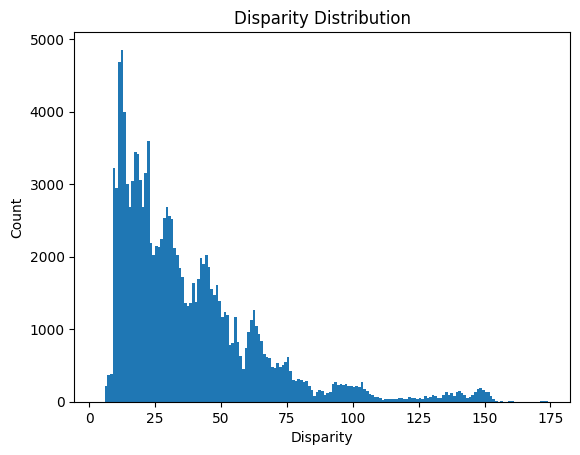

In [11]:

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Ensure disparities are integer encoded
classes = np.unique(median_disp)

# Compute balanced class weights
weights = compute_class_weight(class_weight='balanced', classes=classes, y=median_disp)
class_weight_dict = dict(zip(classes, weights))

# print("Class weights:")
# for k, v in class_weight_dict.items():
#     print(f"Disp {k}: weight {v:.3f}")

import matplotlib.pyplot as plt
plt.hist(median_disp, bins=np.arange(median_disp.min(), median_disp.max()+1))
plt.title("Disparity Distribution")
plt.xlabel("Disparity")
plt.ylabel("Count")
plt.show()



In [12]:

# -----------------------------------------------------------
# Callbacks
# -----------------------------------------------------------
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

# -----------------------------------------------------------
# Train model
# -----------------------------------------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    # callbacks=[early_stop,lr_scheduler,checkpoint_cb,gpu_util,gpu_logger],
    callbacks=[early_stop,checkpoint_cb],
    verbose=1
)


/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/500


/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/tensorflow/python/util/numpy_compat.py:47: RuntimeWarning: overflow encountered in cast
  return np.array(values, copy=copy, order=order).astype(dtype)
I0000 00:00:1761223145.644856  789075 service.cc:152] XLA service 0x7ba158008170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761223145.644879  789075 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-23 18:09:07.545304: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761223158.423149  789075 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-10-23 18:10:01.384020: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_3

    1/14746 ━━━━━━━━━━━━━━━━━━━━ 376:35:56 92s/step - accuracy: 0.0000e+00 - disp_tolerance_acc: 0.2500 - loss: 1.1516

I0000 00:00:1761223202.154010  789075 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  255/14746 ━━━━━━━━━━━━━━━━━━━━ 3:54 16ms/step - accuracy: 0.0072 - disp_tolerance_acc: 0.0366 - loss: 2.4464

2025-10-23 18:10:58.332478: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_3', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_1', 16 bytes spill stores, 16 bytes spill loads



  259/14746 ━━━━━━━━━━━━━━━━━━━━ 53:15 221ms/step - accuracy: 0.0072 - disp_tolerance_acc: 0.0367 - loss: 2.4455

2025-10-23 18:10:59.248077: W external/local_xla/xla/stream_executor/cuda/cuda_command_buffer.cc:668] Retry CUDA graph instantiation after OOM error
2025-10-23 18:10:59.248204: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate graph with 7 nodes and 0 conditionals (total of 0 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory
	 [[{{node StatefulPartitionedCall}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.



ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _

In [ ]:

import numpy as np

# Save
np.save(model_location+"history.npy", history.history)

model.save(model_location+"best_model.keras")
